# HKT Single-Country Production: Terminal-Tail Approximation Analysis

This notebook implements the single-country benchmark requested in `AI_gen_prompts/Approximation_error_in_tails_analysis.md`. It uses the large-bubble calibration matching the two-country `12_v9` exercise and separates three objects:

1. An exact all-`u` HKT path, where the real allocation comes from the static HKT block and the rational bubble share is computed by a long product recursion.
2. An unreduced finite-horizon all-`u` equilibrium solve, where `phi_t` and `q_t` are unknowns and the artificial successor at `T_solve + 1` is built from an extrapolated `phi` rule.
3. A finite-horizon valuation diagnostic, where the solved all-`u` path is decomposed into `V/q` and `B/q` by a separate backward recursion.

The important distinction is that the two-country production solver uses the extrapolated all-`u` successor to solve the equilibrium path backward. In the single-country HKT economy, the unreduced equations algebraically collapse to the static HKT block: `phi_t`, `q_t`, and `d_t` are pinned down by local free-entry/stock-market-clearing conditions at each predetermined `n_t`. The valuation recursion is therefore a separate diagnostic, not the terminal condition for the equilibrium price path.

In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    dir = start_dir
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && return start_dir
        dir = parent
    end
end

const PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)

include(joinpath(PROJECT_DIR, "Single_country_production", "SingleCountryProductionOLG.jl"))

using Printf, Statistics, Markdown, NLsolve, IJulia
using Plots, LaTeXStrings
using Plots.PlotMeasures

gr()
default(size=(940, 560), framestyle=:box, grid=:y, legend=:best,
        fontfamily="Computer Modern", linewidth=2,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=8mm, right_margin=6mm, top_margin=7mm, bottom_margin=8mm)

const OUTDIR = joinpath(PROJECT_DIR, "Single_country_production",
                        "outputs_hkt_single_country_tail_analysis")
isdir(OUTDIR) || mkpath(OUTDIR)

RUN_MODE = Symbol(get(ENV, "TAIL_ANALYSIS_MODE", "replication"))
@assert RUN_MODE in (:replication, :smoke) "RUN_MODE must be :replication or :smoke"

println("Project directory: ", PROJECT_DIR)
println("Output directory:  ", OUTDIR)
println("Run mode:          ", RUN_MODE)

  Activating 

Project directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Output directory:  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Single_country_production/outputs_hkt_single_country_tail_analysis
Run mode:          replication


## 0. Calibration and Grids

Replication mode uses the requested large-bubble calibration:

```julia
p = HKTParams(T=100, gamma=0.25, xiu=2.0, lambdau=1.5, xib=0.5, lambdab=0.5)
pi_persist = 0.80
```

The horizon/buffer grid is `T_report in {45, 60}`, `n_buffer in {0, 5, 20}`, and `T0 in {20, 30, 40}`, with baseline `(45, 5)`. Smoke mode keeps the same primitives but uses tiny grids so the notebook can be executed quickly with `TAIL_ANALYSIS_MODE=smoke`.

In [2]:
p = HKTParams(T=100, γ=0.25, ξu=2.0, λu=1.5, ξb=0.5, λb=0.5)
pi_persist = 0.80

if RUN_MODE == :smoke
    T_REPORT_GRID = [5, 6]
    N_BUFFER_GRID = [0, 2]
    T0_GRID = [2, 4]
    BASELINE_SPEC = (T_report=5, n_buffer=2)
    EXACT_T_EXT = 160
    EXACT_TAIL_K = 30
    TAIL_REGRESSION_K_DEFAULT = 4
    EXPORT_T_MAX = maximum(T_REPORT_GRID)
else
    T_REPORT_GRID = [45, 60]
    N_BUFFER_GRID = [0, 5, 20]
    T0_GRID = [20, 30, 40]
    BASELINE_SPEC = (T_report=45, n_buffer=5)
    EXACT_T_EXT = 600
    EXACT_TAIL_K = 80
    TAIL_REGRESSION_K_DEFAULT = 8
    EXPORT_T_MAX = p.T
end

TERMINAL_RULES = [:flat, :local_loglinear, :asymptotic_hkt, :tail_regression]
TERMINAL_T_REPORT = BASELINE_SPEC.T_report
TERMINAL_BUFFER_GRID = N_BUFFER_GRID

println("Calibration:")
@printf("  beta=%.3f gamma=%.3f alpha=%.3f rho=%.3f theta=%.3f aH=%.3f pi=%.3f\n",
        p.β, p.γ, p.α, p.ρ, p.θ, p.aH, pi_persist)
@printf("  xi_u=%.3f lambda_u=%.3f xi_b=%.3f lambda_b=%.3f\n", p.ξu, p.λu, p.ξb, p.λb)
println("Grid:")
println("  T_report = ", T_REPORT_GRID)
println("  n_buffer = ", N_BUFFER_GRID)
println("  T0       = ", T0_GRID)
println("  baseline = ", BASELINE_SPEC)
println("  exact recursion T_ext = ", EXACT_T_EXT, ", tail_k = ", EXACT_TAIL_K)

Calibration:


  beta=0.500 gamma=0.250 alpha=0.500 rho=2.000 theta=0.500 aH=0.200 pi=0.800
  xi_u=2.000 lambda_u=1.500 xi_b=0.500 lambda_b=0.500
Grid:
  T_report = 

[45, 60]
  n_buffer = [0, 5, 20]
  T0       = [20, 30, 40]
  baseline = (T_report = 45, n_buffer = 5)
  exact recursion T_ext = 600, tail_k = 80


## 1. Notebook-Local Helpers

The source model is left untouched. The helper `hkt_block_given_phi` mirrors `hkt_block` but skips `solve_phi`, which lets the artificial terminal successor use a supplied terminal extrapolation while all reported dates continue to use the exact HKT static block.

In [3]:
stock_price_from_block(block, n) = block.PD_pv * (block.D / n)
per_dividend_from_block(block, n) = block.D / n
positive_for_log(x; floor=1e-300) = max.(Float64.(x), floor)
positive_scalar(x; floor=1e-300) = max(float(x), floor)
phi_clamp(x) = clamp(float(x), 1e-12, 1 - 1e-12)

function pretty(x)
    x === missing && return ""
    x isa Bool && return string(x)
    x isa Integer && return string(x)
    if x isa AbstractFloat
        if !isfinite(x)
            return string(x)
        elseif abs(x) >= 1000 || (abs(x) > 0 && abs(x) < 1e-4)
            return @sprintf("%.3e", x)
        else
            return @sprintf("%.6f", x)
        end
    end
    return string(x)
end

function csv_escape(x)
    x === missing && return ""
    s = string(x)
    if occursin(',', s) || occursin('"', s) || occursin('\n', s)
        return "\"" * replace(s, "\"" => "\"\"") * "\""
    end
    return s
end

function write_csv(filename, rows, cols)
    open(filename, "w") do io
        println(io, join(cols, ","))
        for r in rows
            println(io, join([csv_escape(getproperty(r, Symbol(c))) for c in cols], ","))
        end
    end
    return filename
end

function html_escape(x)
    s = string(x)
    s = replace(s, "&" => "&amp;")
    s = replace(s, "<" => "&lt;")
    s = replace(s, ">" => "&gt;")
    s = replace(s, "\"" => "&quot;")
    return s
end

function markdown_table(rows, cols; maxrows=length(rows))
    isempty(rows) && return IJulia.HTML("<p><em>No rows.</em></p>")
    io = IOBuffer()
    print(io, "<div style=\"overflow-x:auto;max-width:100%;\"><table style=\"border-collapse:collapse;font-size:90%;\">")
    print(io, "<thead><tr>")
    for c in cols
        print(io, "<th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">", html_escape(c), "</th>")
    end
    print(io, "</tr></thead><tbody>")
    for r in rows[1:min(maxrows, length(rows))]
        print(io, "<tr>")
        for c in cols
            print(io, "<td style=\"border:1px solid #ddd;padding:4px 6px;white-space:nowrap;\">", html_escape(pretty(getproperty(r, Symbol(c)))), "</td>")
        end
        print(io, "</tr>")
    end
    print(io, "</tbody></table></div>")
    return IJulia.HTML(String(take!(io)))
end

function hkt_block_given_phi(p::HKTParams, n::Float64, z::Symbol, phi::Real)
    φ = phi_clamp(phi)
    ξ, λ = z === :u ? (p.ξu, p.λu) : (p.ξb, p.λb)
    AXH = p.A_XH * n^ξ
    ALL = p.A_LL * n^λ
    Xtilde = AXH * φ
    Ltilde = ALL
    FX = _ces_FX(p.α, p.ρ, Xtilde, Ltilde)
    FL = _ces_FL(p.α, p.ρ, Xtilde, Ltilde)
    HwH = p.θ * FX * AXH
    LwL = FL * ALL
    e = HwH + LwL
    D = (1 - p.θ) / p.θ * HwH * φ
    d = D / n
    PD_pv = p.θ / ((1 - p.θ) * φ * p.aH)
    q = PD_pv * d
    G = 1 + p.aH * (1 - φ)
    PD_agg = G * PD_pv
    mc_resid = G * HwH / p.aH - p.β * e
    return (; φ, e, D, d, PD_pv, PD_agg, q, G, mc_resid)
end

function geom_ratio_tail(x::AbstractVector{<:Real}; k::Int=80)
    T = length(x)
    T < 3 && return (r=NaN, tail=0.0)
    k = clamp(k, 2, T - 1)
    idx = collect((T - k + 1):T)
    vals = max.(Float64.(x[idx]), eps(Float64))
    xs = Float64.(idx)
    ys = log.(vals)
    xbar, ybar = mean(xs), mean(ys)
    denom = sum(abs2, xs .- xbar)
    denom <= 0 && return (r=NaN, tail=0.0)
    slope = sum((xs .- xbar) .* (ys .- ybar)) / denom
    r = exp(slope)
    tail = (0 < r < 1) ? vals[end] * r / (1 - r) : 0.0
    return (r=r, tail=tail)
end

function hkt_rational_bubble_path(p::HKTParams; pi_persist::Float64=0.80,
                                  T_ext::Int=600, tail_k::Int=80)
    @assert 0 < pi_persist < 1
    p_ext = HKTParams(β=p.β, γ=p.γ, α=p.α, ρ=p.ρ, θ=p.θ,
                      A_XH=p.A_XH, A_LL=p.A_LL,
                      ξu=p.ξu, λu=p.λu, ξb=p.ξb, λb=p.λb,
                      aH=p.aH, n0=p.n0, T=T_ext)

    n = Vector{Float64}(undef, T_ext + 1)
    n[1] = p_ext.n0
    q_u = zeros(T_ext + 1); d_u = zeros(T_ext + 1)
    q_b = zeros(T_ext + 1); d_b = zeros(T_ext + 1)
    phi_u = zeros(T_ext + 1); G_u = zeros(T_ext + 1)

    for i in 1:(T_ext + 1)
        u = hkt_block(p_ext, n[i], :u)
        b = hkt_block(p_ext, n[i], :b)
        q_u[i] = stock_price_from_block(u, n[i])
        d_u[i] = per_dividend_from_block(u, n[i])
        q_b[i] = stock_price_from_block(b, n[i])
        d_b[i] = per_dividend_from_block(b, n[i])
        phi_u[i], G_u[i] = u.φ, u.G
        i <= T_ext && (n[i + 1] = u.G * n[i])
    end

    factor = zeros(T_ext)
    for i in 1:T_ext
        den = pi_persist * (q_u[i + 1] + d_u[i + 1])^(1 - p_ext.γ) +
              (1 - pi_persist) * (q_b[i + 1] + d_b[i + 1])^(1 - p_ext.γ)
        m_u = q_u[i] * (q_u[i + 1] + d_u[i + 1])^(-p_ext.γ) / den
        factor[i] = pi_persist * m_u * q_u[i + 1] / q_u[i]
    end

    loss = -log.(clamp.(factor, eps(Float64), 1.0))
    tail = geom_ratio_tail(loss; k=tail_k)

    log_share = zeros(T_ext + 1)
    running = tail.tail
    log_share[T_ext + 1] = -running
    for i in T_ext:-1:1
        running += loss[i]
        log_share[i] = -running
    end

    bubble_share = exp.(log_share)
    B = q_u .* bubble_share
    V = q_u .- B
    fundamental_share = V ./ q_u

    return (; t=collect(0:T_ext), n, q_u, d_u, q_b, d_b, V, B,
            fundamental_share, bubble_share, factor, loss,
            tail_ratio=tail.r, tail_loss=tail.tail,
            phi_u, G_u, pi_persist, T_ext)
end

hkt_rational_bubble_path (generic function with 1 method)

## 2. Exact Benchmark and Tail-Approximated Recursion

The exact benchmark uses the static HKT block at every all-`u` date and computes the rational bubble share using a long product recursion. The finite-horizon equilibrium comparison mirrors the two-country terminal-successor construction as far as the single-country system allows: it solves for `phi_t` and `q_t` on `t = 0, ..., T_solve`, extrapolates `phi_{T_solve+1}`, and computes all artificial successor objects implied by that extrapolated `phi`.

The key result is expected to be degeneracy, not instability. In the unreduced single-country HKT equations, stock-market clearing plus the innovation/free-entry price identity imply the same static `phi_t` condition used by `hkt_block`. The one-period pricing equation with the notebook SDF is an identity once successor payoffs are supplied. Thus the artificial all-`u` successor is still computed, but it does not discipline earlier `q_t` values the way it can in the two-country production solver.

In [4]:
function local_loglinear_next_phi(phi::AbstractVector{<:Real})
    length(phi) >= 2 || return phi_clamp(phi[end])
    a, b = phi[end - 1], phi[end]
    (isfinite(a) && isfinite(b) && a > 0 && b > 0) || return phi_clamp(b)
    return phi_clamp(b * b / a)
end

function tail_regression_next_phi(phi::AbstractVector{<:Real}; k::Int=8)
    T = length(phi)
    lo = max(1, T - k + 1)
    idx = [i for i in lo:T if isfinite(phi[i]) && phi[i] > 0]
    length(idx) >= 3 || return local_loglinear_next_phi(phi)
    x = Float64.(idx .- 1)
    y = log.([phi[i] for i in idx])
    xbar, ybar = mean(x), mean(y)
    denom = sum(abs2, x .- xbar)
    denom <= 0 && return local_loglinear_next_phi(phi)
    slope = sum((x .- xbar) .* (y .- ybar)) / denom
    intercept = ybar - slope * xbar
    return phi_clamp(exp(intercept + slope * T))
end

function asymptotic_hkt_next_phi(p::HKTParams, phi_T::Real)
    φ = phi_clamp(phi_T)
    ψ = (p.ξu - p.λu) * (p.ρ - 1)
    G = 1 + p.aH * (1 - φ)
    rate = G^(-ψ / p.ρ)
    return (isfinite(rate) && rate > 0) ? phi_clamp(φ * rate) : φ
end

function terminal_next_phi(phi::AbstractVector{<:Real}, p::HKTParams, rule::Symbol; k::Int=8)
    rule == :flat && return phi_clamp(phi[end])
    rule == :local_loglinear && return local_loglinear_next_phi(phi)
    rule == :asymptotic_hkt && return asymptotic_hkt_next_phi(p, phi[end])
    rule == :tail_regression && return tail_regression_next_phi(phi; k=k)
    error("Unknown terminal rule: $rule")
end

function build_tail_approx_path(p::HKTParams; pi_persist::Float64, T_report::Int,
                                n_buffer::Int, rule::Symbol,
                                tail_regression_k::Int=8)
    @assert 0 < pi_persist < 1
    @assert T_report >= 1
    @assert n_buffer >= 0
    T_solve = T_report + n_buffer
    N = T_solve + 2                       # t = 0, ..., T_solve plus artificial T_solve+1

    n = Vector{Float64}(undef, N)
    n[1] = p.n0
    phi = zeros(N); G = zeros(N); q = zeros(N); d = zeros(N)
    e = zeros(N); D = zeros(N); PD = zeros(N); mc_resid = zeros(N)
    q_b = zeros(N); d_b = zeros(N); phi_b = zeros(N)

    for i in 1:(T_solve + 1)
        u = hkt_block(p, n[i], :u)
        b = hkt_block(p, n[i], :b)
        phi[i], G[i], q[i], d[i] = u.φ, u.G, stock_price_from_block(u, n[i]), per_dividend_from_block(u, n[i])
        e[i], D[i], PD[i], mc_resid[i] = u.e, u.D, u.PD_pv, u.mc_resid
        phi_b[i], q_b[i], d_b[i] = b.φ, stock_price_from_block(b, n[i]), per_dividend_from_block(b, n[i])
        n[i + 1] = u.G * n[i]
    end

    terminal_phi = terminal_next_phi(phi[1:(T_solve + 1)], p, rule; k=tail_regression_k)
    uT = hkt_block_given_phi(p, n[N], :u, terminal_phi)
    bT = hkt_block(p, n[N], :b)
    phi[N], G[N], q[N], d[N] = uT.φ, uT.G, uT.q, uT.d
    e[N], D[N], PD[N], mc_resid[N] = uT.e, uT.D, uT.PD_pv, uT.mc_resid
    phi_b[N], q_b[N], d_b[N] = bT.φ, stock_price_from_block(bT, n[N]), per_dividend_from_block(bT, n[N])

    V = zeros(N)
    V[N] = q[N]
    for i in (N - 1):-1:1
        den = pi_persist * (q[i + 1] + d[i + 1])^(1 - p.γ) +
              (1 - pi_persist) * (q_b[i + 1] + d_b[i + 1])^(1 - p.γ)
        m_u = q[i] * (q[i + 1] + d[i + 1])^(-p.γ) / den
        m_b = q[i] * (q_b[i + 1] + d_b[i + 1])^(-p.γ) / den
        V[i] = pi_persist * m_u * (d[i + 1] + V[i + 1]) +
               (1 - pi_persist) * m_b * (d_b[i + 1] + q_b[i + 1])
    end

    B = q .- V
    fundamental_share = V ./ q
    bubble_share = B ./ q

    return (; T_report, n_buffer, T_solve, terminal_rule=rule,
            t=collect(0:(T_solve + 1)), n, phi, G, q, d, e, D, PD, mc_resid,
            phi_b, q_b, d_b, V, B, fundamental_share, bubble_share,
            terminal_phi, terminal_q=q[N], terminal_d=d[N], terminal_mc_resid=mc_resid[N],
            artificial_successor_index=N)
end

function exact_rows_from_fv(fv, Tmax::Int)
    rows = NamedTuple[]
    for i in 1:(Tmax + 1)
        push!(rows, (;
            t=fv.t[i], n=fv.n[i], phi=fv.phi_u[i], G=fv.G_u[i],
            q=fv.q_u[i], d=fv.d_u[i], dividend_yield=fv.d_u[i] / fv.q_u[i],
            V=fv.V[i], B=fv.B[i], fundamental_share=fv.fundamental_share[i],
            bubble_share=fv.bubble_share[i], pi_persist=fv.pi_persist,
            T_ext=fv.T_ext, tail_ratio=fv.tail_ratio, tail_loss=fv.tail_loss))
    end
    return rows
end

function tail_rows_from_case(case)
    rows = NamedTuple[]
    for i in 1:(case.T_report + 1)
        push!(rows, (;
            T_report=case.T_report, n_buffer=case.n_buffer,
            terminal_rule=String(case.terminal_rule), T_solve=case.T_solve,
            t=case.t[i], periods_to_terminal=case.T_solve - case.t[i],
            n=case.n[i], phi=case.phi[i], G=case.G[i], q=case.q[i], d=case.d[i],
            dividend_yield=case.d[i] / case.q[i], V=case.V[i], B=case.B[i],
            fundamental_share=case.fundamental_share[i], bubble_share=case.bubble_share[i],
            terminal_phi=case.terminal_phi, terminal_q=case.terminal_q,
            terminal_mc_resid=case.terminal_mc_resid))
    end
    return rows
end

function error_metrics(case, fv, T0::Int)
    T = min(T0, case.T_report)
    idx = 1:(T + 1)
    log_phi = maximum(abs.(log.(positive_for_log(case.phi[idx])) .- log.(positive_for_log(fv.phi_u[idx]))))
    log_q = maximum(abs.(log.(positive_for_log(case.q[idx])) .- log.(positive_for_log(fv.q_u[idx]))))
    log_dq = maximum(abs.(log.(positive_for_log(case.d[idx] ./ case.q[idx])) .-
                          log.(positive_for_log(fv.d_u[idx] ./ fv.q_u[idx]))))
    vshare = maximum(abs.(case.fundamental_share[idx] .- fv.fundamental_share[idx]))
    bshare = maximum(abs.(case.bubble_share[idx] .- fv.bubble_share[idx]))
    return (max_log_phi_error=log_phi,
            max_log_q_error=log_q,
            max_log_dividend_yield_error=log_dq,
            max_fundamental_share_error=vshare,
            max_bubble_share_error=bshare)
end

function error_row(case, fv, T0::Int)
    return merge((;
        T_report=case.T_report, n_buffer=case.n_buffer,
        terminal_rule=String(case.terminal_rule), T0=T0,
        benchmark="exact_hkt_long_product", T_solve=case.T_solve,
        terminal_phi=case.terminal_phi, terminal_mc_resid=case.terminal_mc_resid),
        error_metrics(case, fv, T0))
end

function bubble_diagnostic_row(case, fv, T0::Int)
    T = min(T0, case.T_report)
    idx = 1:(T + 1)
    err = case.bubble_share[idx] .- fv.bubble_share[idx]
    jlocal = argmax(abs.(err))
    j = idx[jlocal]
    endpoint = case.T_report + 1
    return (;
        T_report=case.T_report, n_buffer=case.n_buffer,
        terminal_rule=String(case.terminal_rule), T0=T0,
        t_max=case.t[j], max_abs_bubble_share_error=abs(err[jlocal]),
        bubble_share_at_t=case.bubble_share[j], exact_bubble_share_at_t=fv.bubble_share[j],
        fundamental_share_at_t=case.fundamental_share[j], exact_fundamental_share_at_t=fv.fundamental_share[j],
        abs_log_q_error_at_t=abs(log(positive_scalar(case.q[j])) - log(positive_scalar(fv.q_u[j]))),
        abs_log_phi_error_at_t=abs(log(positive_scalar(case.phi[j])) - log(positive_scalar(fv.phi_u[j]))),
        periods_to_terminal_at_t=case.T_solve - case.t[j],
        endpoint_t=case.t[endpoint], endpoint_bubble_share=case.bubble_share[endpoint],
        exact_endpoint_bubble_share=fv.bubble_share[endpoint],
        endpoint_fundamental_share=case.fundamental_share[endpoint],
        exact_endpoint_fundamental_share=fv.fundamental_share[endpoint],
        terminal_phi=case.terminal_phi, terminal_mc_resid=case.terminal_mc_resid)
end

bubble_diagnostic_row (generic function with 1 method)

## 3. Exact HKT Path

The exact path is computed once and reused as the benchmark for all error tables. The reported real-side variables use the static HKT block; the exact `V/q` and `B/q` shares use the long rational-bubble product recursion.

In [5]:
exact_fv = hkt_rational_bubble_path(p; pi_persist=pi_persist,
                                    T_ext=EXACT_T_EXT, tail_k=EXACT_TAIL_K)
exact_rows = exact_rows_from_fv(exact_fv, EXPORT_T_MAX)
exact_cols = ["t", "n", "phi", "G", "q", "d", "dividend_yield", "V", "B",
              "fundamental_share", "bubble_share", "pi_persist", "T_ext",
              "tail_ratio", "tail_loss"]
write_csv(joinpath(OUTDIR, "single_country_exact_paths.csv"), exact_rows, exact_cols)

@printf("Exact rational recursion: T_ext=%d tail_ratio=%.6f tail_loss=%.4e\n",
        exact_fv.T_ext, exact_fv.tail_ratio, exact_fv.tail_loss)
markdown_table(exact_rows[[1, min(2, length(exact_rows)), min(11, length(exact_rows)),
                           min(21, length(exact_rows)), length(exact_rows)]],
               ["t", "phi", "q", "dividend_yield", "fundamental_share", "bubble_share"];
               maxrows=5)

Exact rational recursion: T_ext=600 tail_ratio=0.955443 tail_loss=1.3322e-11


t,phi,q,dividend_yield,fundamental_share,bubble_share
0,0.693303,0.794495,0.138661,0.999815,0.000185
1,0.683741,0.820128,0.136748,0.999739,0.000261
10,0.591198,1.139540,0.118240,0.996412,0.003588
20,0.480133,1.806783,0.096027,0.972743,0.027257
100,0.023937,865.042059,0.004787,0.098688,0.901312


## 4. Unreduced Finite-Horizon Equilibrium Comparison

This is the correct equilibrium-path comparison for the artificial all-`u` successor question. For each finite horizon and terminal rule, the solver treats `phi_t` and `q_t` as unknowns on `t = 0, ..., T_solve`. Given a candidate `phi` path, it computes production objects and knowledge growth forward with `hkt_block_given_phi`. The residual enforces:

- the innovation/free-entry price identity, `q_t = q_t^{HKT}(phi_t, n_t)`;
- stock-market clearing, `n_{t+1} q_t = beta e_t`.

The extrapolated all-`u` successor is still constructed and the one-step pricing residual is reported. In this single-country calibration that pricing residual is numerically zero because the SDF formula is normalized by `q_t`; this is the algebraic reason the unreduced solve returns the exact HKT static path.

In [6]:
logit(φ) = log(φ / (1 - φ))
logistic(x) = 1 / (1 + exp(-x))

function exact_static_path(p::HKTParams, T_solve::Int)
    N = T_solve + 1
    n = Vector{Float64}(undef, N + 1)
    n[1] = p.n0
    phi = zeros(N); G = zeros(N); q = zeros(N); d = zeros(N)
    e = zeros(N); D = zeros(N); PD = zeros(N); mc_resid = zeros(N)
    for i in 1:N
        u = hkt_block(p, n[i], :u)
        phi[i], G[i] = u.φ, u.G
        q[i], d[i] = stock_price_from_block(u, n[i]), per_dividend_from_block(u, n[i])
        e[i], D[i], PD[i], mc_resid[i] = u.e, u.D, u.PD_pv, u.mc_resid
        n[i + 1] = u.G * n[i]
    end
    return (; T_solve, t=collect(0:T_solve), n=n[1:N], n_successor=n[N + 1],
            phi, G, q, d, e, D, PD, mc_resid)
end

function unpack_unreduced(x, N)
    phi = [phi_clamp(logistic(x[i])) for i in 1:N]
    q = exp.(x[(N + 1):(2N)])
    return phi, q
end

function unreduced_residual!(F, x, p::HKTParams, T_solve::Int)
    N = T_solve + 1
    phi, q = unpack_unreduced(x, N)
    n = p.n0
    for i in 1:N
        u = hkt_block_given_phi(p, n, :u, phi[i])
        n_next = u.G * n
        F[i] = (q[i] - u.q) / max(abs(u.q), 1e-12)
        F[N + i] = (n_next * q[i] - p.β * u.e) / max(abs(p.β * u.e), 1e-12)
        n = n_next
    end
    return nothing
end

function build_unreduced_path(p::HKTParams, phi, q; T_report::Int, n_buffer::Int,
                              rule::Symbol, pi_persist::Float64,
                              tail_regression_k::Int=8)
    T_solve = T_report + n_buffer
    N = T_solve + 1
    n = Vector{Float64}(undef, N + 1)
    n[1] = p.n0
    G = zeros(N); d = zeros(N); e = zeros(N); D = zeros(N); PD = zeros(N)
    mc_resid = zeros(N); q_static = zeros(N); clearing_resid = zeros(N)
    q_b = zeros(N + 1); d_b = zeros(N + 1)

    for i in 1:N
        u = hkt_block_given_phi(p, n[i], :u, phi[i])
        b = hkt_block(p, n[i], :b)
        G[i], d[i], e[i], D[i], PD[i] = u.G, u.d, u.e, u.D, u.PD_pv
        mc_resid[i], q_static[i] = u.mc_resid, u.q
        q_b[i], d_b[i] = stock_price_from_block(b, n[i]), per_dividend_from_block(b, n[i])
        n[i + 1] = u.G * n[i]
        clearing_resid[i] = n[i + 1] * q[i] - p.β * u.e
    end

    terminal_phi = terminal_next_phi(phi, p, rule; k=tail_regression_k)
    terminal_u = hkt_block_given_phi(p, n[N + 1], :u, terminal_phi)
    terminal_b = hkt_block(p, n[N + 1], :b)
    q_b[N + 1] = stock_price_from_block(terminal_b, n[N + 1])
    d_b[N + 1] = per_dividend_from_block(terminal_b, n[N + 1])

    pricing_resid = zeros(N)
    for i in 1:N
        q_u_next = i < N ? q[i + 1] : terminal_u.q
        d_u_next = i < N ? d[i + 1] : terminal_u.d
        q_b_next = q_b[i + 1]
        d_b_next = d_b[i + 1]
        den = pi_persist * (q_u_next + d_u_next)^(1 - p.γ) +
              (1 - pi_persist) * (q_b_next + d_b_next)^(1 - p.γ)
        m_u = q[i] * (q_u_next + d_u_next)^(-p.γ) / den
        m_b = q[i] * (q_b_next + d_b_next)^(-p.γ) / den
        rhs = pi_persist * m_u * (q_u_next + d_u_next) +
              (1 - pi_persist) * m_b * (q_b_next + d_b_next)
        pricing_resid[i] = q[i] - rhs
    end

    return (; T_report, n_buffer, T_solve, terminal_rule=rule,
            t=collect(0:T_solve), n=n[1:N], n_successor=n[N + 1],
            phi, G, q, d, e, D, PD, mc_resid, q_static, clearing_resid,
            pricing_resid, terminal_phi, terminal_q=terminal_u.q,
            terminal_d=terminal_u.d, terminal_G=terminal_u.G,
            terminal_mc_resid=terminal_u.mc_resid,
            max_free_entry_resid=maximum(abs.(q .- q_static)),
            max_clearing_resid=maximum(abs.(clearing_resid)),
            max_pricing_identity_resid=maximum(abs.(pricing_resid)),
            terminal_pricing_identity_resid=pricing_resid[end])
end

function run_unreduced_tail_case(p::HKTParams; T_report::Int, n_buffer::Int,
                                 rule::Symbol, pi_persist::Float64,
                                 tail_regression_k::Int=8)
    T_solve = T_report + n_buffer
    guess = exact_static_path(p, T_solve)
    N = T_solve + 1
    x0 = vcat(logit.(guess.phi), log.(guess.q))
    sol = nlsolve((F, x) -> unreduced_residual!(F, x, p, T_solve), x0;
                  xtol=1e-11, ftol=1e-11, iterations=200, show_trace=false)
    F_check = similar(x0)
    unreduced_residual!(F_check, sol.zero, p, T_solve)
    phi_sol, q_sol = unpack_unreduced(sol.zero, N)
    path = build_unreduced_path(p, phi_sol, q_sol;
                                T_report=T_report, n_buffer=n_buffer,
                                rule=rule, pi_persist=pi_persist,
                                tail_regression_k=tail_regression_k)
    summary = (; T_report, n_buffer, terminal_rule=String(rule), T_solve,
               converged=converged(sol), iterations=sol.iterations,
               max_residual=maximum(abs.(F_check)),
               max_free_entry_resid=path.max_free_entry_resid,
               max_clearing_resid=path.max_clearing_resid,
               max_pricing_identity_resid=path.max_pricing_identity_resid,
               terminal_pricing_identity_resid=path.terminal_pricing_identity_resid,
               terminal_phi=path.terminal_phi, terminal_q=path.terminal_q,
               terminal_mc_resid=path.terminal_mc_resid)
    return (; path..., summary)
end

function unreduced_path_rows(case)
    rows = NamedTuple[]
    for i in 1:(case.T_report + 1)
        push!(rows, (;
            comparison_type="unreduced_equilibrium", T_report=case.T_report,
            n_buffer=case.n_buffer, terminal_rule=String(case.terminal_rule),
            T_solve=case.T_solve, t=case.t[i], periods_to_terminal=case.T_solve - case.t[i],
            n=case.n[i], phi=case.phi[i], G=case.G[i], q=case.q[i], d=case.d[i],
            dividend_yield=case.d[i] / case.q[i], free_entry_resid=case.q[i] - case.q_static[i],
            clearing_resid=case.clearing_resid[i], pricing_identity_resid=case.pricing_resid[i],
            terminal_phi=case.terminal_phi, terminal_q=case.terminal_q,
            terminal_mc_resid=case.terminal_mc_resid))
    end
    return rows
end

function unreduced_error_metrics(case, fv, T0::Int)
    T = min(T0, case.T_report)
    idx = 1:(T + 1)
    return (max_log_phi_error=maximum(abs.(log.(positive_for_log(case.phi[idx])) .-
                                           log.(positive_for_log(fv.phi_u[idx])))),
            max_log_q_error=maximum(abs.(log.(positive_for_log(case.q[idx])) .-
                                         log.(positive_for_log(fv.q_u[idx])))),
            max_log_dividend_yield_error=maximum(abs.(log.(positive_for_log(case.d[idx] ./ case.q[idx])) .-
                                                       log.(positive_for_log(fv.d_u[idx] ./ fv.q_u[idx])))),
            max_pricing_identity_resid=maximum(abs.(case.pricing_resid[idx])),
            max_free_entry_resid=maximum(abs.(case.q[idx] .- case.q_static[idx])),
            max_clearing_resid=maximum(abs.(case.clearing_resid[idx])))
end

function unreduced_error_row(case, fv, T0::Int; benchmark="exact_hkt_static_block")
    return merge((;
        comparison_type="unreduced_equilibrium", T_report=case.T_report,
        n_buffer=case.n_buffer, terminal_rule=String(case.terminal_rule),
        T0=T0, benchmark=benchmark, T_solve=case.T_solve,
        converged=case.summary.converged, iterations=case.summary.iterations,
        solver_max_residual=case.summary.max_residual,
        terminal_phi=case.terminal_phi, terminal_q=case.terminal_q,
        terminal_mc_resid=case.terminal_mc_resid),
        unreduced_error_metrics(case, fv, T0))
end

unreduced_horizon_cases = Any[]
for T_report in T_REPORT_GRID, n_buffer in N_BUFFER_GRID
    push!(unreduced_horizon_cases,
          Base.invokelatest(run_unreduced_tail_case, p;
                            T_report=T_report, n_buffer=n_buffer,
                            rule=:local_loglinear, pi_persist=pi_persist,
                            tail_regression_k=TAIL_REGRESSION_K_DEFAULT))
end

unreduced_terminal_cases = Any[]
for n_buffer in TERMINAL_BUFFER_GRID, rule in TERMINAL_RULES
    push!(unreduced_terminal_cases,
          Base.invokelatest(run_unreduced_tail_case, p;
                            T_report=TERMINAL_T_REPORT, n_buffer=n_buffer,
                            rule=rule, pi_persist=pi_persist,
                            tail_regression_k=TAIL_REGRESSION_K_DEFAULT))
end

unreduced_path_rows_all = reduce(vcat, [unreduced_path_rows(c) for c in unreduced_horizon_cases])
unreduced_path_cols = ["comparison_type", "T_report", "n_buffer", "terminal_rule", "T_solve", "t",
                       "periods_to_terminal", "n", "phi", "G", "q", "d", "dividend_yield",
                       "free_entry_resid", "clearing_resid", "pricing_identity_resid",
                       "terminal_phi", "terminal_q", "terminal_mc_resid"]
write_csv(joinpath(OUTDIR, "single_country_tail_approx_paths.csv"),
          unreduced_path_rows_all, unreduced_path_cols)

unreduced_horizon_rows = NamedTuple[]
for c in unreduced_horizon_cases, T0 in T0_GRID
    push!(unreduced_horizon_rows, unreduced_error_row(c, exact_fv, T0))
end
unreduced_terminal_rows = NamedTuple[]
for c in unreduced_terminal_cases, T0 in T0_GRID
    push!(unreduced_terminal_rows, unreduced_error_row(c, exact_fv, T0))
end
unreduced_error_cols = ["comparison_type", "T_report", "n_buffer", "terminal_rule", "T0",
                        "benchmark", "T_solve", "converged", "iterations",
                        "solver_max_residual", "terminal_phi", "terminal_q",
                        "terminal_mc_resid", "max_log_phi_error", "max_log_q_error",
                        "max_log_dividend_yield_error", "max_pricing_identity_resid",
                        "max_free_entry_resid", "max_clearing_resid"]
write_csv(joinpath(OUTDIR, "single_country_horizon_buffer_errors.csv"),
          unreduced_horizon_rows, unreduced_error_cols)
write_csv(joinpath(OUTDIR, "single_country_terminal_rule_sensitivity.csv"),
          unreduced_terminal_rows, unreduced_error_cols)

unreduced_summary_rows = [c.summary for c in vcat(unreduced_horizon_cases, unreduced_terminal_cases)]
unreduced_summary_cols = ["T_report", "n_buffer", "terminal_rule", "T_solve", "converged",
                          "iterations", "max_residual", "max_free_entry_resid",
                          "max_clearing_resid", "max_pricing_identity_resid",
                          "terminal_pricing_identity_resid", "terminal_phi", "terminal_q",
                          "terminal_mc_resid"]
write_csv(joinpath(OUTDIR, "single_country_unreduced_solver_check.csv"),
          unreduced_summary_rows, unreduced_summary_cols)

plot_T0_unreduced = maximum(T0_GRID)
plot_rows_unreduced = filter(r -> r.T0 == plot_T0_unreduced, unreduced_horizon_rows)
x_unred = 1:length(plot_rows_unreduced)
labels_unred = ["T=$(r.T_report), b=$(r.n_buffer)" for r in plot_rows_unreduced]
p_unred_err = plot(x_unred, [r.max_log_phi_error for r in plot_rows_unreduced],
                   marker=:circle, lw=2.1, xticks=(x_unred, labels_unred), xrotation=35,
                   ylabel="max log error", title="Unreduced equilibrium errors through T0=$plot_T0_unreduced",
                   label=L"\log\phi")
plot!(p_unred_err, x_unred, [r.max_log_q_error for r in plot_rows_unreduced],
      marker=:square, lw=2.1, label=L"\log q")
plot!(p_unred_err, x_unred, [r.max_log_dividend_yield_error for r in plot_rows_unreduced],
      marker=:diamond, lw=2.1, label=L"\log(d/q)")
savefig(p_unred_err, joinpath(OUTDIR, "single_country_unreduced_horizon_buffer_errors.png"))

baseline_unreduced_idx = findfirst(c -> c.T_report == BASELINE_SPEC.T_report &&
                                        c.n_buffer == BASELINE_SPEC.n_buffer,
                                   unreduced_horizon_cases)
@assert baseline_unreduced_idx !== nothing "Baseline unreduced case not found"
baseline_unreduced = unreduced_horizon_cases[baseline_unreduced_idx]
len_unred = baseline_unreduced.T_report + 1
tt_unred = baseline_unreduced.t[1:len_unred]
p_unred_phi = plot(tt_unred, exact_fv.phi_u[1:len_unred], color=:black, lw=3,
                   xlabel="t", ylabel=L"\phi_t", title="Unreduced baseline: phi", label="exact")
plot!(p_unred_phi, tt_unred, baseline_unreduced.phi[1:len_unred], color=:crimson, lw=2, ls=:dash,
      label="unreduced")
p_unred_q = plot(tt_unred, exact_fv.q_u[1:len_unred], color=:black, lw=3,
                 xlabel="t", ylabel=L"q_t", title="Unreduced baseline: q", yscale=:log10, label="exact")
plot!(p_unred_q, tt_unred, baseline_unreduced.q[1:len_unred], color=:crimson, lw=2, ls=:dash,
      label="unreduced")
p_unred_dq = plot(tt_unred, exact_fv.d_u[1:len_unred] ./ exact_fv.q_u[1:len_unred], color=:black, lw=3,
                  xlabel="t", ylabel=L"d_t/q_t", title="Unreduced baseline: d/q", label="exact")
plot!(p_unred_dq, tt_unred, baseline_unreduced.d[1:len_unred] ./ baseline_unreduced.q[1:len_unred],
      color=:crimson, lw=2, ls=:dash, label="unreduced")
fig_unreduced_baseline = plot(p_unred_phi, p_unred_q, p_unred_dq, layout=(3, 1),
                              size=(980, 900), bottom_margin=8mm)
savefig(fig_unreduced_baseline, joinpath(OUTDIR, "single_country_unreduced_exact_vs_static_paths.png"))

plot_buffer_unred = BASELINE_SPEC.n_buffer in TERMINAL_BUFFER_GRID ? BASELINE_SPEC.n_buffer : first(TERMINAL_BUFFER_GRID)
plot_cases_unred = filter(c -> c.n_buffer == plot_buffer_unred, unreduced_terminal_cases)
p_term_phi_unred = plot(tt_unred, exact_fv.phi_u[1:len_unred], color=:black, lw=3,
                        title="Unreduced terminal-rule sensitivity: phi", xlabel="t", ylabel=L"\phi_t", label="exact")
p_term_q_unred = plot(tt_unred, exact_fv.q_u[1:len_unred], color=:black, lw=3,
                      title="Unreduced terminal-rule sensitivity: q", xlabel="t", ylabel=L"q_t", yscale=:log10, label="exact")
p_term_dq_unred = plot(tt_unred, exact_fv.d_u[1:len_unred] ./ exact_fv.q_u[1:len_unred], color=:black, lw=3,
                       title="Unreduced terminal-rule sensitivity: d/q", xlabel="t", ylabel=L"d_t/q_t", label="exact")
for c in plot_cases_unred
    label = String(c.terminal_rule)
    plot!(p_term_phi_unred, tt_unred, c.phi[1:len_unred], lw=2, label=label)
    plot!(p_term_q_unred, tt_unred, c.q[1:len_unred], lw=2, label=label)
    plot!(p_term_dq_unred, tt_unred, c.d[1:len_unred] ./ c.q[1:len_unred], lw=2, label=label)
end
fig_unreduced_terminal = plot(p_term_phi_unred, p_term_q_unred, p_term_dq_unred,
                              layout=(3, 1), size=(980, 900), bottom_margin=8mm)
savefig(fig_unreduced_terminal, joinpath(OUTDIR, "single_country_unreduced_terminal_rule_sensitivity_paths.png"))

markdown_table(unreduced_horizon_rows,
    ["T_report", "n_buffer", "T0", "max_log_phi_error", "max_log_q_error",
     "max_log_dividend_yield_error", "max_pricing_identity_resid",
     "max_free_entry_resid", "max_clearing_resid"]; maxrows=length(unreduced_horizon_rows))

T_report,n_buffer,T0,max_log_phi_error,max_log_q_error,max_log_dividend_yield_error,max_pricing_identity_resid,max_free_entry_resid,max_clearing_resid
45,0,20,2.220e-16,0.000000,4.441e-16,2.220e-16,8.882e-16,5.329e-15
45,0,30,2.220e-16,0.000000,1.332e-15,8.882e-16,2.220e-15,2.842e-14
45,0,40,2.220e-16,0.000000,1.332e-15,1.776e-15,2.665e-15,1.705e-13
45,5,20,2.220e-16,0.000000,4.441e-16,2.220e-16,8.882e-16,5.329e-15
45,5,30,2.220e-16,0.000000,1.332e-15,8.882e-16,2.220e-15,2.842e-14
45,5,40,2.220e-16,0.000000,1.332e-15,1.776e-15,2.665e-15,1.705e-13
45,20,20,2.220e-16,0.000000,4.441e-16,2.220e-16,8.882e-16,5.329e-15
45,20,30,2.220e-16,0.000000,1.332e-15,8.882e-16,2.220e-15,2.842e-14
45,20,40,2.220e-16,0.000000,1.332e-15,1.776e-15,2.665e-15,1.705e-13
60,0,20,2.220e-16,0.000000,4.441e-16,2.220e-16,8.882e-16,5.329e-15


## 5. Valuation Diagnostic: Horizon and Buffer Errors

This section keeps the exact/static HKT equilibrium path on reported dates and recomputes only the finite backward `V/q` and `B/q` decomposition. It is not the equilibrium-path terminal-successor comparison; that comparison is the unreduced solve above. The valuation diagnostic is still useful because it isolates how a finite no-tail boundary changes the fundamental/bubble split even when the allocation and stock price are exact.

In [7]:
horizon_cases = [build_tail_approx_path(p; pi_persist=pi_persist,
                                        T_report=T_report, n_buffer=n_buffer,
                                        rule=:local_loglinear,
                                        tail_regression_k=TAIL_REGRESSION_K_DEFAULT)
                 for T_report in T_REPORT_GRID for n_buffer in N_BUFFER_GRID]

baseline_case_idx = findfirst(c -> c.T_report == BASELINE_SPEC.T_report &&
                                   c.n_buffer == BASELINE_SPEC.n_buffer,
                              horizon_cases)
@assert baseline_case_idx !== nothing "Baseline case not found in horizon grid"
baseline_case = horizon_cases[baseline_case_idx]

tail_path_rows = reduce(vcat, [tail_rows_from_case(c) for c in horizon_cases])
tail_path_cols = ["T_report", "n_buffer", "terminal_rule", "T_solve", "t",
                  "periods_to_terminal", "n", "phi", "G", "q", "d",
                  "dividend_yield", "V", "B", "fundamental_share", "bubble_share",
                  "terminal_phi", "terminal_q", "terminal_mc_resid"]
write_csv(joinpath(OUTDIR, "single_country_valuation_tail_approx_paths.csv"), tail_path_rows, tail_path_cols)

horizon_error_rows = NamedTuple[]
for c in horizon_cases, T0 in T0_GRID
    push!(horizon_error_rows, error_row(c, exact_fv, T0))
end

error_cols = ["T_report", "n_buffer", "terminal_rule", "T0", "benchmark", "T_solve",
              "terminal_phi", "terminal_mc_resid", "max_log_phi_error",
              "max_log_q_error", "max_log_dividend_yield_error",
              "max_fundamental_share_error", "max_bubble_share_error"]
write_csv(joinpath(OUTDIR, "single_country_valuation_horizon_buffer_errors.csv"),
          horizon_error_rows, error_cols)

bubble_diag_rows = [bubble_diagnostic_row(c, exact_fv, maximum(T0_GRID)) for c in horizon_cases]
bubble_diag_cols = ["T_report", "n_buffer", "terminal_rule", "T0", "t_max",
                    "max_abs_bubble_share_error", "bubble_share_at_t",
                    "exact_bubble_share_at_t", "fundamental_share_at_t",
                    "exact_fundamental_share_at_t", "abs_log_q_error_at_t",
                    "abs_log_phi_error_at_t", "periods_to_terminal_at_t",
                    "endpoint_t", "endpoint_bubble_share", "exact_endpoint_bubble_share",
                    "endpoint_fundamental_share", "exact_endpoint_fundamental_share",
                    "terminal_phi", "terminal_mc_resid"]
write_csv(joinpath(OUTDIR, "single_country_bubble_share_diagnostics.csv"),
          bubble_diag_rows, bubble_diag_cols)

markdown_table(horizon_error_rows,
    ["T_report", "n_buffer", "T0", "max_log_phi_error", "max_log_q_error",
     "max_log_dividend_yield_error", "max_fundamental_share_error",
     "max_bubble_share_error"]; maxrows=length(horizon_error_rows))

T_report,n_buffer,T0,max_log_phi_error,max_log_q_error,max_log_dividend_yield_error,max_fundamental_share_error,max_bubble_share_error
45,0,20,0.000000,0.000000,0.000000,0.027257,0.027257
45,0,30,0.000000,0.000000,0.000000,0.100807,0.100807
45,0,40,0.000000,0.000000,0.000000,0.229728,0.229728
45,5,20,0.000000,0.000000,0.000000,0.027257,0.027257
45,5,30,0.000000,0.000000,0.000000,0.100807,0.100807
45,5,40,0.000000,0.000000,0.000000,0.229728,0.229728
45,20,20,0.000000,0.000000,0.000000,0.027257,0.027257
45,20,30,0.000000,0.000000,0.000000,0.100807,0.100807
45,20,40,0.000000,0.000000,0.000000,0.229728,0.229728
60,0,20,0.000000,0.000000,0.000000,0.027257,0.027257


In [8]:
function exact_series(fv, name::Symbol, len::Int)
    name == :phi && return fv.phi_u[1:len]
    name == :q && return fv.q_u[1:len]
    name == :dividend_yield && return fv.d_u[1:len] ./ fv.q_u[1:len]
    name == :fundamental_share && return fv.fundamental_share[1:len]
    name == :bubble_share && return fv.bubble_share[1:len]
    error("unknown exact series $name")
end

function case_series(case, name::Symbol, len::Int)
    name == :phi && return case.phi[1:len]
    name == :q && return case.q[1:len]
    name == :dividend_yield && return case.d[1:len] ./ case.q[1:len]
    name == :fundamental_share && return case.fundamental_share[1:len]
    name == :bubble_share && return case.bubble_share[1:len]
    error("unknown case series $name")
end

plot_len = baseline_case.T_report + 1
tt = baseline_case.t[1:plot_len]
series_specs = [(:phi, L"\phi_t", "Labor in production"),
                (:q, L"q_t", "Stock price"),
                (:dividend_yield, L"d_t/q_t", "Dividend yield"),
                (:fundamental_share, L"V_t/q_t", "Fundamental share"),
                (:bubble_share, L"B_t/q_t", "Bubble share")]

panels = Any[]
for (name, ylabel, title) in series_specs
    p_series = plot(tt, exact_series(exact_fv, name, plot_len), lw=2.6,
                    color=:black, label="exact", xlabel="t", ylabel=ylabel,
                    title=title)
    plot!(p_series, tt, case_series(baseline_case, name, plot_len), lw=2.1,
          color=:crimson, linestyle=:dash, label="tail approx baseline")
    name == :q && plot!(p_series, yscale=:log10)
    push!(panels, p_series)
end
push!(panels, plot(framestyle=:none, ticks=false, legend=false))
fig_exact_vs_approx = plot(panels..., layout=(3, 2), size=(1120, 960), bottom_margin=8mm)
savefig(fig_exact_vs_approx, joinpath(OUTDIR, "single_country_exact_vs_approx_paths.png"))

p_bq = plot(title="Horizon/buffer overlays: B/q", xlabel="t", ylabel=L"B_t/q_t", legend=:outerright)
p_vq = plot(title="Horizon/buffer overlays: V/q", xlabel="t", ylabel=L"V_t/q_t", legend=:outerright)
max_report = maximum(T_REPORT_GRID)
plot!(p_bq, exact_fv.t[1:(max_report + 1)], exact_fv.bubble_share[1:(max_report + 1)],
      color=:black, lw=3, label="exact")
plot!(p_vq, exact_fv.t[1:(max_report + 1)], exact_fv.fundamental_share[1:(max_report + 1)],
      color=:black, lw=3, label="exact")
for c in horizon_cases
    len = c.T_report + 1
    label = "T=$(c.T_report), b=$(c.n_buffer)"
    style = (c.T_report == BASELINE_SPEC.T_report && c.n_buffer == BASELINE_SPEC.n_buffer) ? :dash : :solid
    plot!(p_bq, c.t[1:len], c.bubble_share[1:len], lw=2, linestyle=style, label=label)
    plot!(p_vq, c.t[1:len], c.fundamental_share[1:len], lw=2, linestyle=style, label=label)
end
fig_share_overlay = plot(p_bq, p_vq, layout=(2, 1), size=(1040, 840), bottom_margin=8mm)
savefig(fig_share_overlay, joinpath(OUTDIR, "single_country_horizon_buffer_share_overlays.png"))

plot_T0 = maximum(T0_GRID)
plot_rows = filter(r -> r.T0 == plot_T0, horizon_error_rows)
x = 1:length(plot_rows)
labels = ["T=$(r.T_report), b=$(r.n_buffer)" for r in plot_rows]
p_real = plot(x, [r.max_log_phi_error for r in plot_rows], marker=:circle, lw=2.1,
              xticks=(x, labels), xrotation=35, ylabel="max log error",
              title="Real-side errors through T0=$plot_T0", label=L"\log\phi")
plot!(p_real, x, [r.max_log_q_error for r in plot_rows], marker=:square, lw=2.1, label=L"\log q")
plot!(p_real, x, [r.max_log_dividend_yield_error for r in plot_rows], marker=:diamond, lw=2.1,
      label=L"\log(d/q)")
p_val = plot(x, [r.max_fundamental_share_error for r in plot_rows], marker=:circle, lw=2.1,
             xticks=(x, labels), xrotation=35, ylabel="max share error",
             title="Tail-valuation errors through T0=$plot_T0", label=L"V/q")
plot!(p_val, x, [r.max_bubble_share_error for r in plot_rows], marker=:square, lw=2.1, label=L"B/q")
fig_errors = plot(p_real, p_val, layout=(2, 1), size=(1040, 820), bottom_margin=13mm)
savefig(fig_errors, joinpath(OUTDIR, "single_country_horizon_buffer_error_plots.png"))



GKS: Possible loss of precision in routine SET_WINDOW


"/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Single_country_production/outputs_hkt_single_country_tail_analysis/single_country_horizon_buffer_error_plots.png"

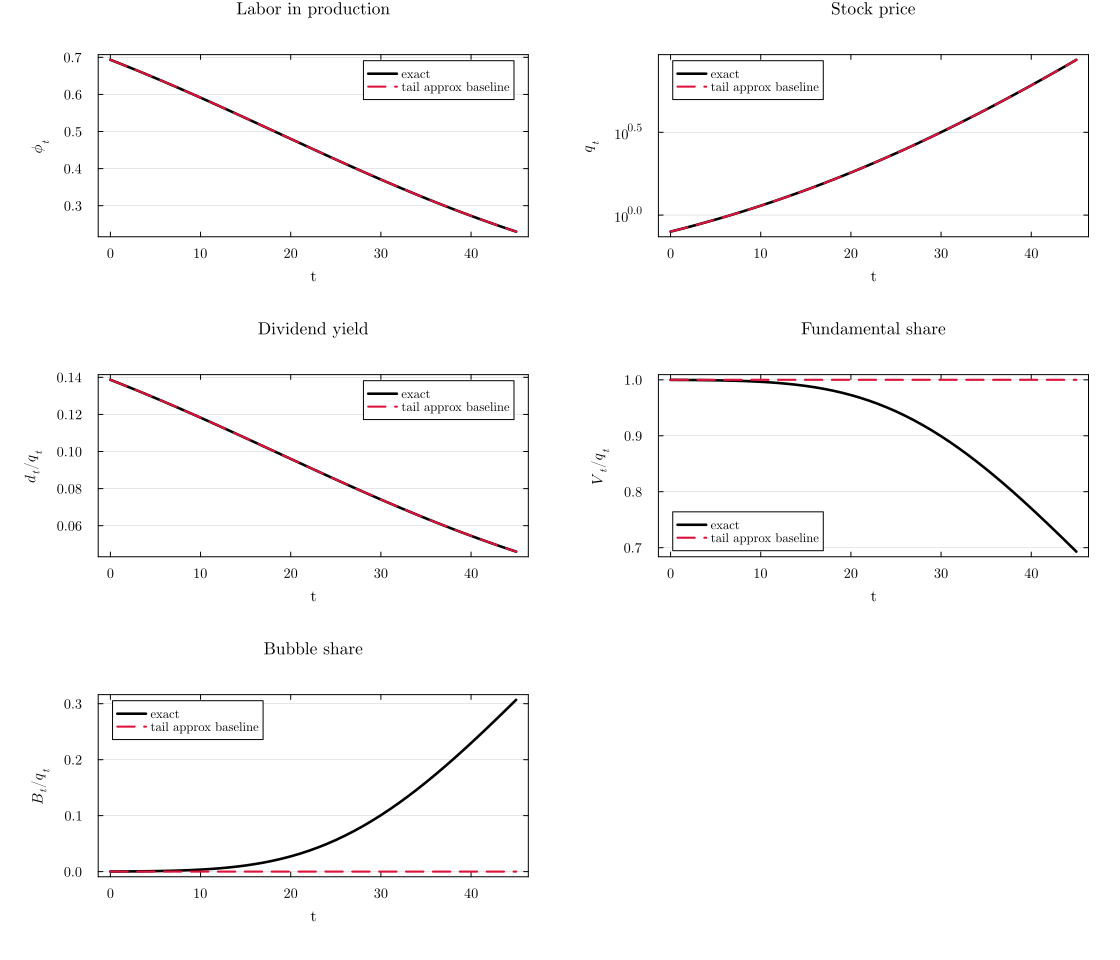

In [9]:
fig_exact_vs_approx

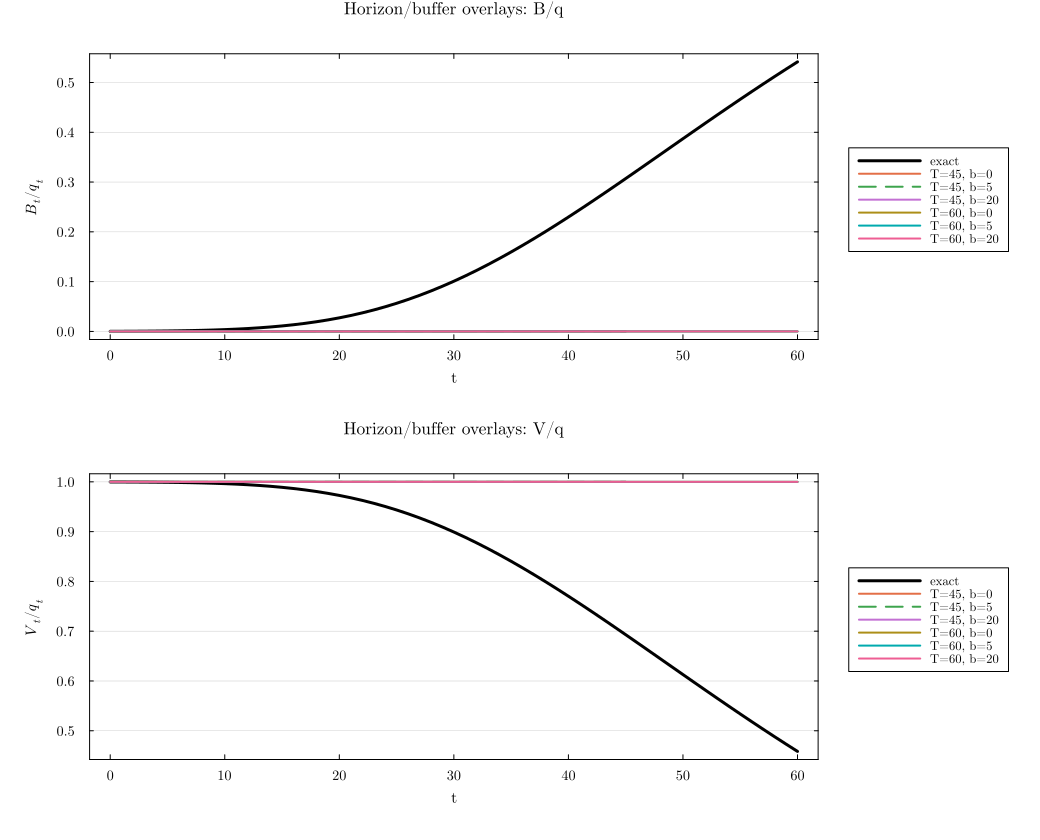

In [10]:
fig_share_overlay

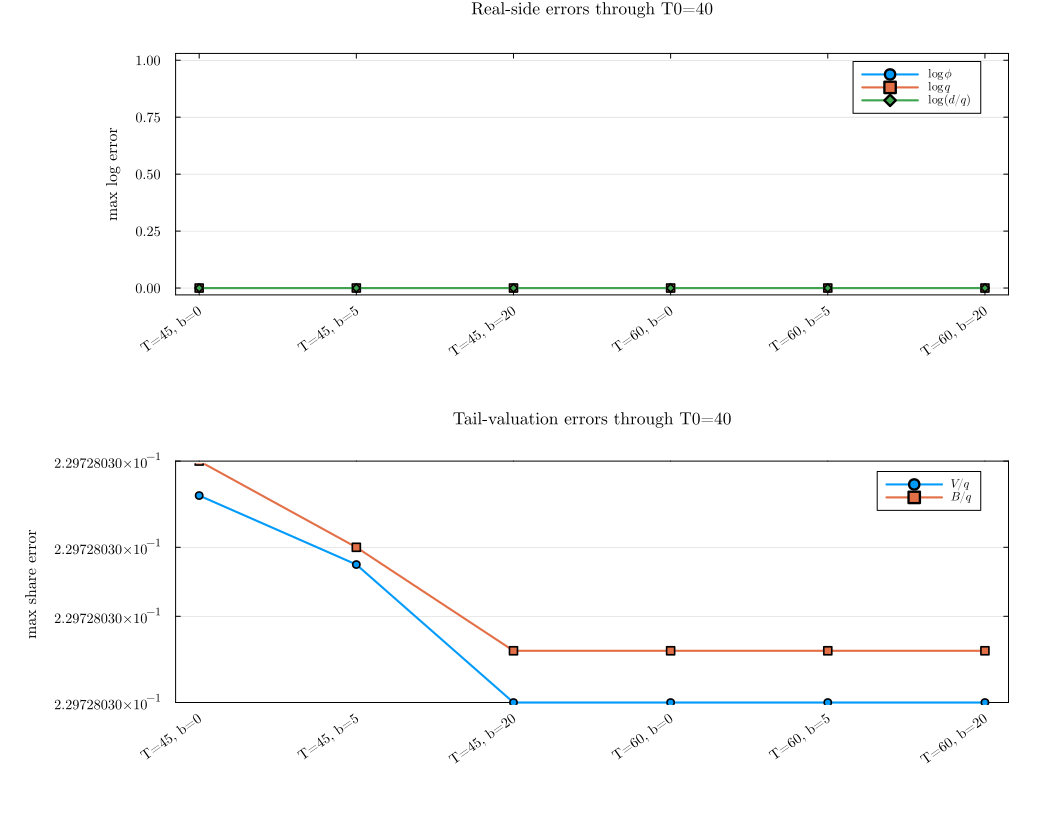

In [11]:
fig_errors

## 6. Valuation Diagnostic: Terminal-Rule Sensitivity

The unreduced equilibrium terminal-rule comparison above shows that `phi`, `q`, and `d/q` are invariant because the single-country equations collapse to the exact HKT static path. This section is narrower: it compares how the separate finite backward valuation diagnostic behaves under the same four artificial successor rules.

With the boundary `V[T_solve+1] = q[T_solve+1]` and the one-step SDF normalized by `q_t`, that recursion collapses to `V_t = q_t` on reported dates. This confirms that the finite no-tail valuation misses the exact rational bubble share rather than contaminating the HKT allocation.

In [12]:
terminal_cases = [build_tail_approx_path(p; pi_persist=pi_persist,
                                         T_report=TERMINAL_T_REPORT,
                                         n_buffer=n_buffer,
                                         rule=rule,
                                         tail_regression_k=TAIL_REGRESSION_K_DEFAULT)
                  for n_buffer in TERMINAL_BUFFER_GRID for rule in TERMINAL_RULES]

terminal_rows = NamedTuple[]
for c in terminal_cases, T0 in T0_GRID
    push!(terminal_rows, error_row(c, exact_fv, T0))
end
terminal_cols = ["T_report", "n_buffer", "terminal_rule", "T0", "benchmark", "T_solve",
                 "terminal_phi", "terminal_mc_resid", "max_log_phi_error",
                 "max_log_q_error", "max_log_dividend_yield_error",
                 "max_fundamental_share_error", "max_bubble_share_error"]
write_csv(joinpath(OUTDIR, "single_country_valuation_terminal_rule_sensitivity.csv"),
          terminal_rows, terminal_cols)

plot_buffer = BASELINE_SPEC.n_buffer in TERMINAL_BUFFER_GRID ? BASELINE_SPEC.n_buffer : first(TERMINAL_BUFFER_GRID)
plot_cases = filter(c -> c.n_buffer == plot_buffer, terminal_cases)
plot_len = TERMINAL_T_REPORT + 1
tt = collect(0:TERMINAL_T_REPORT)

p_phi = plot(tt, exact_fv.phi_u[1:plot_len], color=:black, lw=3,
             title="Terminal-rule sensitivity: phi", xlabel="t", ylabel=L"\phi_t", label="exact")
p_q = plot(tt, exact_fv.q_u[1:plot_len], color=:black, lw=3,
           title="Terminal-rule sensitivity: q", xlabel="t", ylabel=L"q_t", yscale=:log10, label="exact")
p_vq = plot(tt, exact_fv.fundamental_share[1:plot_len], color=:black, lw=3,
            title="Terminal-rule sensitivity: V/q", xlabel="t", ylabel=L"V_t/q_t", label="exact")
p_bq = plot(tt, exact_fv.bubble_share[1:plot_len], color=:black, lw=3,
            title="Terminal-rule sensitivity: B/q", xlabel="t", ylabel=L"B_t/q_t", label="exact")

for c in plot_cases
    label = String(c.terminal_rule)
    plot!(p_phi, tt, c.phi[1:plot_len], lw=2, label=label)
    plot!(p_q, tt, c.q[1:plot_len], lw=2, label=label)
    plot!(p_vq, tt, c.fundamental_share[1:plot_len], lw=2, label=label)
    plot!(p_bq, tt, c.bubble_share[1:plot_len], lw=2, label=label)
end

fig_terminal = plot(p_phi, p_q, p_vq, p_bq, layout=(2, 2), size=(1120, 820), bottom_margin=8mm)
savefig(fig_terminal, joinpath(OUTDIR, "single_country_terminal_rule_sensitivity_paths.png"))

markdown_table(terminal_rows,
    ["n_buffer", "terminal_rule", "T0", "terminal_phi", "max_log_phi_error",
     "max_log_q_error", "max_fundamental_share_error", "max_bubble_share_error"];
    maxrows=length(terminal_rows)), fig_terminal

(HTML{String}("<div style=\"overflow-x:auto;max-width:100%;\"><table style=\"border-collapse:collapse;font-size:90%;\"><thead><tr><th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">n_buffer</th><th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">terminal_rule</th><th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">T0</th><th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">terminal_phi</th><th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">max_log_phi_error</th><th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">max_log_q_error</th><th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">max_fundamental_share_error</th><th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;white-space:nowrap;\">max_bubble_share_error</th></tr></the

## 7. Interpretation

The unreduced finite-horizon solver is the right comparison for the artificial all-`u` successor question. It treats `phi_t` and `q_t` as unknowns and builds the extrapolated all-`u` successor at `T_solve + 1`, matching the two-country logic as closely as the single-country model permits.

The result is algebraic collapse rather than terminal contamination. The unreduced solver returns the exact static HKT path: errors in `phi`, `q`, and `d/q` are numerical zeros across the horizon/buffer and terminal-rule grids. The artificial successor changes terminal diagnostics such as `terminal_phi` and the successor stock-market-clearing residual, but it does not feed back into reported equilibrium prices in the single-country HKT economy.

The nonzero `V/q` and `B/q` errors in the valuation diagnostic come from truncating tail valuation, not from contamination of the equilibrium allocation or stock price. This is the exactly solvable sanity check for the two-country production notebook: it separates the all-`u` terminal-successor construction from the extra dynamic equilibrium feedback that only exists in the full two-country system.